# Tomograf stożkowy - Julia Miśta, Tymon Błaszkowski

## Import bibliotek

In [1]:
import math
import skimage
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.animation as animation
from IPython.display import HTML
from save_dicom import save_as_dicom
import pydicom

## Wyświelanie animacji sinogramu i zrekonstruowanego obrazu - *animate_reconstruction*,  *animate_sinogram*

Funkcje te służą do generowania interaktywnych wizualizacji, które obrazują przebieg symulacji w czasie rzeczywistym. Wykorzystują one klasę animation.FuncAnimation z biblioteki Matplotlib do stworzenia płynnego przejścia między zapisanymi krokami procesów tworzenia sinogramu i rekonstrukcji.

In [2]:
def animate_reconstruction(steps, step_freq):
    fig, ax = plt.subplots(figsize=(5, 5))
    img = ax.imshow(steps[0], cmap='gray')
    title = ax.set_title("Rekonstrukcja")

    ax.axis('off')

    def update(frame):
        img.set_data(steps[frame]) # konkretny obraz z zapisanych kroków
        title.set_text(f"Po {frame * step_freq} rzutach")
        return [img]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(steps),
        interval=200, #czas między klatkami w ms
        blit=True,
        repeat = False
    )

    html = HTML(ani.to_jshtml())
    plt.close(fig)

    display(html)

def animate_sinogram(steps, step_freq):
    fig, ax = plt.subplots(figsize=(5, 5))
    img = ax.imshow(steps[0], cmap='gray', aspect='auto')
    title = ax.set_title("Sinogram")

    def update(frame):
        img.set_data(steps[frame])
        title.set_text(f"Po {frame * step_freq} rzutach")
        return [img]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(steps),
        interval=200,
        blit=True,
        repeat = False
    )

    html = HTML(ani.to_jshtml())
    plt.close(fig)

    display(html)

## Filtrowanie wyjściowego obrazu

In [3]:
def create_filter_kernel():
    size = 61
    kernel = np.zeros(size)
    center = size // 2
    
    for i in range(size):
        k = i - center
        if k == 0:
            kernel[i] = 1
        elif k % 2 == 0:
            kernel[i] = 0
        else:
            kernel[i] = (-4 / (np.pi**2)) / (k**2)
            
    return kernel

def apply_filter(sinogram):
    kernel = create_filter_kernel()
    filtered_sinogram = np.zeros_like(sinogram)
    
    for i in range(len(sinogram)):
        filtered_sinogram[i, :] = np.convolve(sinogram[i, :], kernel, mode='same')
        
    return filtered_sinogram

## RMSE - *calculate_rmse*

Funkcja calculate_rmse oblicza błąd średniokwadratowy między obrazem oryginalnym a zrekonstruowanym, stosując normalizację Min-Max w celu ujednolicenia skali jasności obu obrazów i zapewnienia obiektywnego porównania ich struktur.

In [4]:
def calculate_rmse(original, reconstructed):
    # sprowadzenie obu obrazów do zakresu 0.0 - 1.0
    orig = original.astype(np.float64)
    if orig.max() > 0:
        orig /= orig.max()
        
    # skalowanie rekonstrukcji 
    reco = reconstructed.astype(np.float64)
    r_min, r_max = reco.min(), reco.max()
    if r_max > r_min:
        reco = (reco - r_min) / (r_max - r_min)
    
    mse = np.mean((orig - reco) ** 2)
    return np.sqrt(mse)

## Funkcja *detectorCords*
Funkcja służąca do wyliczenia lokalizacji - współrzędnych x,y danego dektektora.  

Wejście:  
 * a - wartość kąta na którym znajduje się dany emiter poruszając się po okręgu  
 * i - numer emitera  
 * phi - rozpietość kątowa między emiterami  
 * r - promień trajektorii układu pomiarowego, określający stałą odległość emitera i detektorów od środka obrotu (środka obrazu)  
 
Wyjście:  
 * xd, yd - współrzędne detektora

In [5]:
def detectorCords(a,n,phi,r,i):

    if i == 0:
        xd = r * math.cos(a + math.pi - phi/2)
        yd = r * math.sin(a + math.pi - phi/2)
    elif i == n-1:
        xd = r * math.cos(a + math.pi + phi/2)
        yd = r * math.sin(a + math.pi + phi/2)
    else: #di
        xd = r * math.cos(a + math.pi - phi/2 + i * phi/(n-1))
        yd = r * math.sin(a + math.pi - phi/2 + i * phi/(n-1))

    return xd, yd

## Funkcja *get_pixels_on_line*
Funkcja służąca do wyznaczania współrzędnych pikseli leżących na odcinku łączącym emiter z detektorem.

Wejście:  
 * x1,y1 - współrzędne emitera
 * x2,y2 - współrzędne detektora 
 
Wyjście:  
 * rows - zawiera indeksy wierszy (y) wszystkich pikseli na linii
 * cols -  zawiera indeksy kolumn (x) wszystkich pikseli na linii

In [6]:
def get_pixels_on_line(x1, y1, x2, y2):
    start_y, start_x = int(round(y1)), int(round(x1))
    end_y, end_x = int(round(y2)), int(round(x2))
    rows, cols = skimage.draw.line_nd((start_y, start_x), (end_y, end_x), endpoint=True)
    return rows, cols

## Wczytywanie obrazu
Wczytanie pliku wejściowego, konwersja z formatu RGB na skalę szarości oraz ujednolicenie rozmiaru obrazu do 256x256 px. Na koniec wartości pikseli są przeskalowane do zakresu [0, 255].

In [7]:
def prepare_img(photo):
    img = skimage.io.imread(photo)
    if len(img.shape) == 3:
        img_grey = skimage.color.rgb2gray(img)
    else:
        img_grey = img

    img_grey = skimage.transform.resize(img_grey, (256, 256))
    img_grey = (img_grey * 255).astype(np.uint8)

    return img_grey

img1 = prepare_img("tomograf-obrazy/Shepp_logan.JPG")
img2 = prepare_img("tomograf-obrazy/SADDLE_PE.JPG")
img3 = prepare_img("tomograf-obrazy/CT_ScoutView-large.jpg")

test_images = {"Shepp-Logan": img1, "Saddle PE": img2}

## Tworzenie sinogramu - *generate_sinogram*
Funkcja generate_sinogram symuluje proces skanowania obiektu poprzez obrót układu emiter-detektory o $360^\circ$. Dla każdego położenia kątowego oblicza ona średnią intensywność pikseli wzdłuż linii rzutu, tworząc wynikową macierz projekcji. Dodatkowo funkcja rejestruje stany pośrednie całego procesu, co pozwala na późniejszą animację powstawania sinogramu.

In [8]:
def generate_sinogram(delta_a, n, phi_deg, img):
    sinogram_steps = []
    curr_h, curr_w = img.shape
    r = math.sqrt(curr_w**2 + curr_h**2) / 2 + 10 
    phi = math.radians(phi_deg)
    
    angles = np.arange(0, 360, delta_a)
    num_steps = len(angles)
    sinogram = np.zeros((num_steps, n))
    offset_x, offset_y = curr_w / 2, curr_h / 2

    num_snapshots = 20
    step_freq = max(1, len(angles) // num_snapshots)

    for view, current_angle in enumerate(angles):
        current_angle_rad = math.radians(current_angle)
        xe = r * math.cos(current_angle_rad)
        ye = r * math.sin(current_angle_rad)
        
        for D in range(n):
            xd, yd = detectorCords(current_angle_rad, n, phi, r, D)
            rows, cols = get_pixels_on_line(xe + offset_x, ye + offset_y, 
                                            xd + offset_x, yd + offset_y)
            rows = np.array(rows)
            cols = np.array(cols)
            mask = (rows >= 0) & (rows < curr_h) & (cols >= 0) & (cols < curr_w) #czy piksele są w granicach obrazu
            pixels = img[rows[mask], cols[mask]]
            
            if len(pixels) > 0:
                sinogram[view, D] = np.mean(pixels) #srednia z jasnosci pikseli

        if view % step_freq == 0 or view == len(angles) - 1:
            temp_sino = np.zeros_like(sinogram)
            temp_sino[:view+1, :] = sinogram[:view+1, :]
            sinogram_steps.append(temp_sino)

    return sinogram, sinogram_steps, step_freq, angles

## Rekonstrukcja obrazu z sinogramu - *reconstruction_process*
Funkcja reconstruction_process odtwarza obraz z sinogramu. Po nałożeniu filtru w celu wyostrzenia krawędzi, wartości rzutów są iteracyjnie nanoszone na macierz obrazu pod odpowiednimi kątami. Wynikowy obraz powstaje poprzez uśrednienie skumulowanych danych i skalowanie ich intensywności. Całość procesu jest rejestrowana w krokach, co pozwala na animację powstawania rekonstrukcji.

In [9]:
def reconstruction_process(sinogram, angles, n, phi, r, offset_x, offset_y, curr_h, curr_w, step_freq):

    filtered_sinogram = apply_filter(sinogram)
    reconstruction = np.zeros((curr_h, curr_w))
    reco_no_filter = np.zeros((curr_h, curr_w))
    hits = np.zeros((curr_h, curr_w))
    reconstruction_steps = [] 
    
    num_steps = len(angles)

    for view, current_angle in enumerate(angles):
        current_angle_rad = math.radians(current_angle)
        xe = r * math.cos(current_angle_rad)
        ye = r * math.sin(current_angle_rad)
        
        for D in range(n):
            val_nf = sinogram[view, D]
            val = filtered_sinogram[view, D]
            xd, yd = detectorCords(current_angle_rad, n, phi, r, D)
            rows, cols = get_pixels_on_line(xe + offset_x, ye + offset_y, 
                                            xd + offset_x, yd + offset_y)
            
            mask = (rows >= 0) & (rows < curr_h) & (cols >= 0) & (cols < curr_w)
            reconstruction[rows[mask], cols[mask]] += val
            reco_no_filter[rows[mask], cols[mask]] += val_nf
            hits[rows[mask], cols[mask]] += 1

        if view % step_freq == 0 or view == len(angles) - 1:
            temp = np.divide(reconstruction, hits, out=np.zeros_like(reconstruction), where=hits!=0)
            reconstruction_steps.append(temp.copy())

    final = np.divide(reconstruction, hits, out=np.zeros_like(reconstruction), where=hits!=0) #srednia z sumy jasnosci i liczby trafien
    v_min, v_max = np.percentile(final, (5, 99)) #skalowanie intensywności, aby uniknąć wpływu ekstremalnych wartości
    final_scaled = skimage.exposure.rescale_intensity(final, in_range=(v_min, v_max)) #skalowanie do zakresu 0-1 z uwzględnieniem percentyli
    steps_scaled = [skimage.exposure.rescale_intensity(s, in_range=(v_min, v_max)) for s in reconstruction_steps]

    final_nf = np.divide(reco_no_filter, hits, out=np.zeros_like(reco_no_filter), where=hits!=0)
    final_nf_scaled = skimage.exposure.rescale_intensity(final_nf)
    
    return final_scaled, final_nf_scaled, steps_scaled

## Wyświetlanie wyników - *display_results*

Funkcja display_results odpowiada za końcowe porównanie danych na trzech płaszczyznach. Generuje ona zestawienie obrazów, które pozwala na wizualną ocenę jakości symulacji:

* obraz oryginalny
* sinogram: graficzna reprezentacja zebranych rzutów (danych surowych)
* rekonstrukcja: obraz wynikowy uzyskany po zastosowaniu algorytmu rzutowania wstecznego

In [10]:
def display_results(img_grey, sinogram, reconstructed_plot, reco_nf, num_steps, use_filter):
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    ax[0].imshow(img_grey, cmap='gray')
    ax[0].set_title("Original Image")
    ax[1].imshow(sinogram, cmap='gray', aspect='auto')
    ax[1].set_title(f"Sinogram\n({num_steps} views)")
    if use_filter:
        ax[2].imshow(reconstructed_plot, cmap='gray')
        ax[2].set_title("Reconstruction")
    else:
        ax[2].imshow(reco_nf, cmap='gray')
        ax[2].set_title("Reconstruction\n(No Filter)")
    
    ds = pydicom.dcmread("out.dcm")

    print(f"Pacjent: {ds.PatientName}")
    print(f"ID Pacjenta: {ds.PatientID}")
    print(f"Komentarze: {ds.ImageComments}")
    date1 = ds.ContentDate
    date = date1[0:4] + "." + date1[5:6] + "." + date1[6:]
    print(f"Data: {date}")

    plt.show()

## Funkcja *run_simulation*
Funkcja run_simulation integruje cały proces symulacji. Odpowiada za konfigurację geometrii układu, wygenerowanie sinogramu oraz przeprowadzenie rekonstrukcji obrazu. Następnie zarządza prezentacją danych: wyświetla statyczne porównanie obrazów, eksportuje finalny wynik do formatu DICOM wraz z metadanymi pacjenta oraz uruchamia interaktywne animacje obrazujące przebieg całego badania.

In [11]:
def run_simulation(delta_a, n, phi_deg, name, patient_id, comments, use_filter):
    active_img = img1
    h, w = active_img.shape
    r = math.sqrt(w**2 + h**2) / 2 + 10
    phi_rad = math.radians(phi_deg)
    offset_x, offset_y = w / 2, h / 2
    
    sinogram, sino_steps, step_freq, angles = generate_sinogram(delta_a, n, phi_deg, active_img)
    
    reconstruction, reco_nf,  reco_steps = reconstruction_process(sinogram, angles, n, phi_rad, r, 
        offset_x, offset_y, h, w, step_freq)
    
    patient_data = {"PatientName": name, "PatientID": patient_id, "ImageComments": comments}
    final_dcm = (reconstruction * 255).astype(np.uint8)
    save_as_dicom("out.dcm", final_dcm, patient_data)

    display_results(active_img, sinogram, reconstruction, reco_nf, len(angles), use_filter)
    
    animate_sinogram(sino_steps, step_freq)
    animate_reconstruction(reco_steps, step_freq)


## Graficzny interfejs użytkownika

Użytkownik może samodzielnie definiować geometrię układu (krok kątowy, liczba detektorów, rozpiętość wachlarza) oraz zarządzać metadanymi medycznymi (dane pacjenta, opis badania).

In [12]:
style = {'description_width': '120px'}
interact_manual(
    run_simulation,
    delta_a = widgets.FloatSlider(value=2.0, min=0.5, max=10.0, step=0.5, description='Krok (Δα):', style=style),
    n = widgets.IntSlider(value=180, min=70, max=360, step=10, description='Detektory (n):', style=style),
    phi_deg = widgets.IntSlider(value=180, min=10, max=270, step=5, description='Rozpiętość (φ°):', style=style),
    name = widgets.Text(value='Jan Kowalski', description='Pacjent:', style=style),
    patient_id = widgets.Text(value='12345', description='ID Pacjenta:', style=style),
    comments = widgets.Textarea(value='Skan testowy', description='Komentarze:', style=style),
    use_filter=widgets.Checkbox(value=True, description='Użyj Filtra')
);

interactive(children=(FloatSlider(value=2.0, description='Krok (Δα):', max=10.0, min=0.5, step=0.5, style=Slid…

## Analiza błedu średniokwadratowego

Zmiana błędu średniokwadratowego podczas wykonywania kolejnych iteracji odwrotnej transformaty Radona dla wybranego obrazu

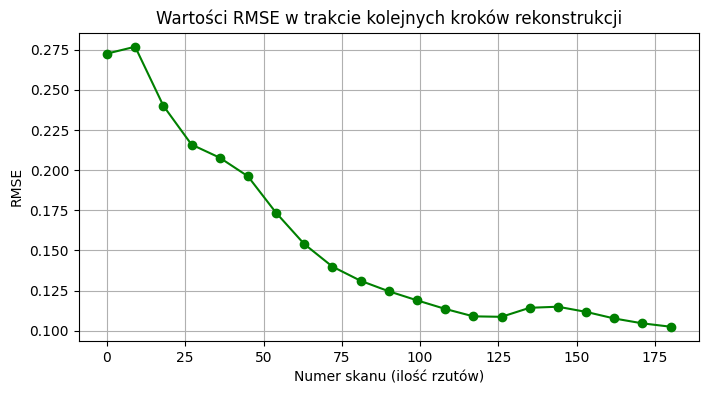

In [13]:
test_n = 180     
test_phi = 180    
test_step = 2.0   
sino, sino_steps, step_freq, angles = generate_sinogram(test_step, test_n, test_phi, img3)

h, w = img3.shape
r = math.sqrt(w**2 + h**2) / 2 + 10
offset_x, offset_y = w / 2, h / 2

reco_f, reco_nf, steps = reconstruction_process(sino, angles, test_n, math.radians(test_phi), r, offset_x, offset_y, h, w, step_freq)

iter_rmse = []
for s in steps:
    s_rescaled = s * 255 if s.max() <= 1.0 else s
    iter_rmse.append(calculate_rmse(img3, s_rescaled))

x_values = [i * step_freq for i in range(len(iter_rmse))]
plt.figure(figsize=(8, 4))
plt.plot(x_values, iter_rmse, color='green', marker='o')
plt.title("Wartości RMSE w trakcie kolejnych kroków rekonstrukcji")
plt.xlabel("Numer skanu (ilość rzutów)")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

Błąd RMSE maleje z każdą iteracją. Po przekroczeniu 125 iteracji zmniejsza się on niewiele, lekko oscylując.

Zmiana błędu średniokwadratowego przy zwiększaniu dokładności próbkowania (trzy uprzednio wymienione parametry modelu emiter/detektor)

* zmiana liczby detektorów - n

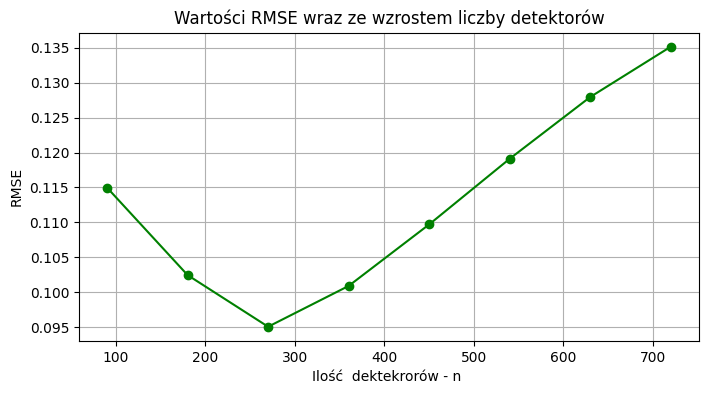

In [14]:
detectors_list = [90, 180, 270, 360, 450, 540, 630, 720]
n_rmse = []

for n_val in detectors_list:
    sino, _, sf, ang = generate_sinogram(2.0, n_val, 180, img3)
    rf, _, _ = reconstruction_process(sino, ang, n_val, math.radians(180), r, offset_x, offset_y, h, w, sf)
    n_rmse.append(calculate_rmse(img3, rf))

plt.figure(figsize=(8, 4))
plt.plot(detectors_list, n_rmse, color='green', marker='o')
plt.title("Wartości RMSE wraz ze wzrostem liczby detektorów")
plt.xlabel("Ilość  dektekrorów - n ")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

Na początku błąd RMSE maleje wraz ze wzrostem liczby detektorów. Po przekroczeniu 270 zawraca i zaczyna rosnąć. Liczba 270 zdaje się być optymalna dla użytej w tym przykładzie rozdzielczości obrazka. Po jej przekroczeniu nie jesteśmy w stanie polepszyć czytelności zdjęcia i dodając detektory jedynie je spłaszczamy.

* zmiana liczby skanów 

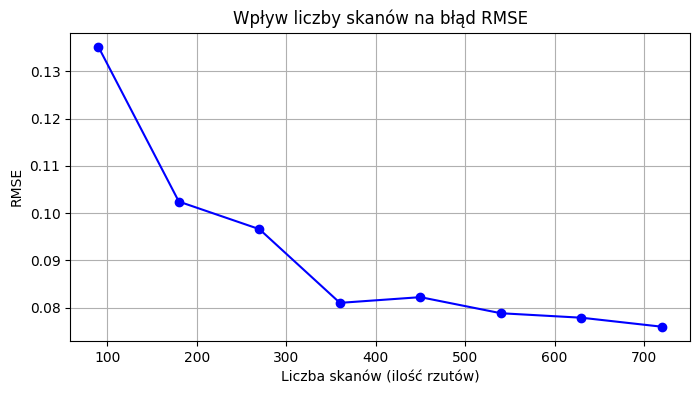

In [15]:
scans_list = [90, 180, 270, 360, 450, 540, 630, 720]
scans_rmse = []

default_n = 180
default_phi = 180

for s_val in scans_list:
    step = 360.0 / s_val
    
    sino, _, sf, ang = generate_sinogram(step, default_n, default_phi, img3)
    rf, _, _ = reconstruction_process(sino, ang, default_n, math.radians(default_phi), r, offset_x, offset_y, h, w, sf)
    
    scans_rmse.append(calculate_rmse(img3, rf))

plt.figure(figsize=(8, 4))
plt.plot(scans_list, scans_rmse, color='blue', marker='o')
plt.title("Wpływ liczby skanów na błąd RMSE")
plt.xlabel("Liczba skanów (ilość rzutów)")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

Błąd RMSE maleje bardzo szybko w przedziale do 350 skanów. Później zmienia się on niewiele.

* zmiana rozpiętności wachlarza

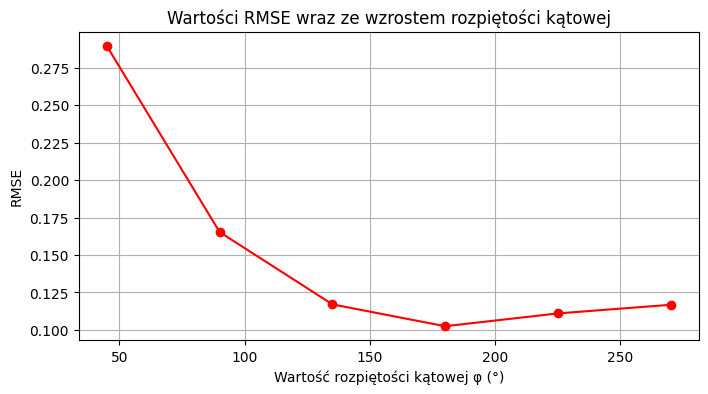

In [16]:
phi_list = [45, 90, 135, 180, 225, 270]
phi_rmse = []

for p_val in phi_list:
    sino, _, sf, ang = generate_sinogram(2.0, 180, p_val, img3)
    rf, _, _ = reconstruction_process(sino, ang, 180, math.radians(p_val), r, offset_x, offset_y, h, w, sf)
    phi_rmse.append(calculate_rmse(img3, rf))

plt.figure(figsize=(8, 4))
plt.plot(phi_list, phi_rmse, color='red', marker='o')
plt.title("Wartości RMSE wraz ze wzrostem rozpiętości kątowej")
plt.xlabel("Wartość rozpiętości kątowej φ (°)")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

Błąd RMSE maleje w przedziale do 180 stopni. Póżniej zaczyna rosnąć. Jest do zgodne z oczekiwaniami, gdyż koło na którym porusza się skaner jest w przypadku naszego programu większe od obrazu, przez co dodatkowe skanery nie sięgałyby go nawet i wprowadzałyby jedynie niechciane artefakty w obrazie końcowym.

Zmiana błędu średniokwadratowego po włączeniu filtrowania.


Shepp-Logan
RMSE (z filtrowaniem):    0.0712
RMSE (bez filtrowania):   0.3934


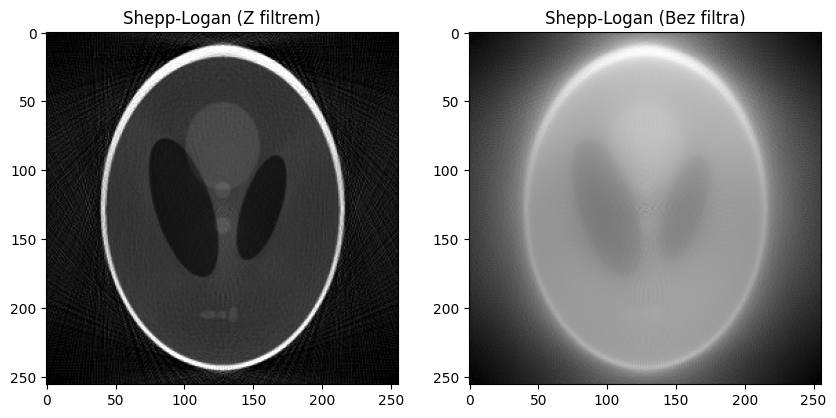


Saddle PE
RMSE (z filtrowaniem):    0.1348
RMSE (bez filtrowania):   0.2694


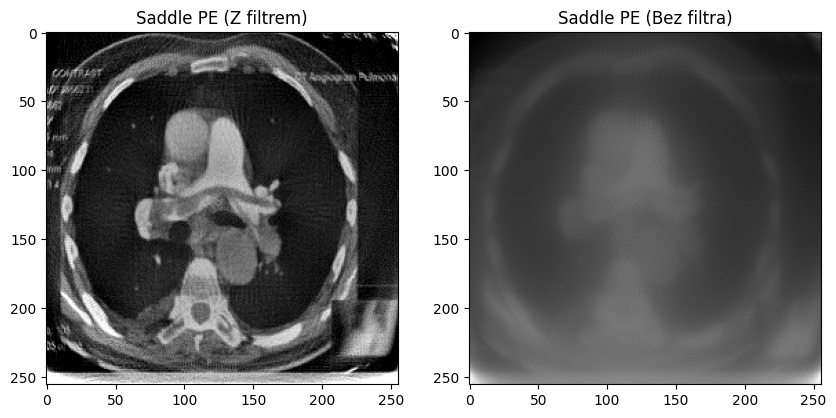

In [17]:
n_test = 360
step_test = 1 #360 skanow, czyli o 1 stopien
phi_test = 270 

for name, img_data in test_images.items():
    sino, _, sf, ang = generate_sinogram(step_test, n_test, phi_test, img_data)
    reco_f, reco_nf, _ = reconstruction_process(sino, ang, n_test, math.radians(phi_test), r, offset_x, offset_y, h, w, sf)
    
    rmse_f = calculate_rmse(img_data, reco_f)
    rmse_nf = calculate_rmse(img_data, reco_nf)
    
    print(f"\n{name}")
    print(f"RMSE (z filtrowaniem):    {rmse_f:.4f}")
    print(f"RMSE (bez filtrowania):   {rmse_nf:.4f}")
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(reco_f, cmap='gray'); ax[0].set_title(f"{name} (Z filtrem)")
    ax[1].imshow(reco_nf, cmap='gray'); ax[1].set_title(f"{name} (Bez filtra)")
    plt.show()